# Toxic Comment Classification (Jigsaw Dataset)

Multi-label classification of Wikipedia talk-page comments into six toxicity
categories: `toxic`, `severe_toxic`, `obscene`, `threat`, `insult`, `identity_hate`.
A comment can carry multiple labels at once (e.g. `toxic` + `insult` + `identity_hate`
simultaneously), so this is genuinely **multi-label**, not multi-class.

**This notebook covers:**
1. Exploratory data analysis
2. Baseline model: TF-IDF + Logistic Regression
3. Neural network: BiLSTM (multi-label, sigmoid outputs)
4. Per-label threshold tuning
5. Model comparison
6. Error analysis (false positives/negatives)
7. Identity-term bias check
8. Conclusions & limitations

**Note on content:** because this dataset's subject is toxic language, some outputs
below (word-frequency plots, error examples) necessarily display offensive language
and slurs. This is unavoidable for the analysis to be meaningful and is presented
purely for classification/bias-auditing purposes.

In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader

import json
import os
import re
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

from data_utils import (
    LABEL_COLS,
    ToxicMultiLabelDataset,
    build_vocab,
    load_official_test_set,
    save_vocab,
)
from model import ToxicMultiLabelClassifier

In [4]:
os.makedirs("artifacts", exist_ok=True)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
RNG = np.random.RandomState(SEED)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

## 1. Load data

In [5]:
df = pd.read_csv("data/train.csv")
test_df = load_official_test_set()

train_df, val_df = train_test_split(df, test_size=0.1, random_state=SEED)

print(
    f"Train: {len(train_df):,}  Val: {len(val_df):,}  "
    f"Official test (filtered): {len(test_df):,}"
)
df.head(3)

Train: 143,613  Val: 15,958  Official test (filtered): 63,978


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 2. Exploratory Data Analysis

### 2.1 Label distribution (severe class imbalance)

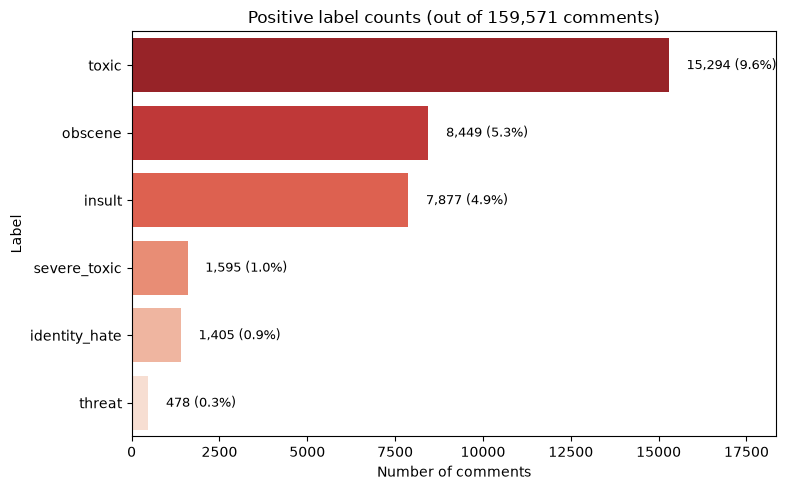


89.8% of comments are fully clean (zero labels)


In [9]:
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    x=label_counts.values,
    y=label_counts.index.tolist(),
    hue=label_counts.index,
    palette="Reds_r",
    legend=False,
)
ax.set_ylabel("Label")
ax.set_xlim(0, label_counts.values.max() * 1.2)
for i, v in enumerate(label_counts.values):
    ax.text(v + 500, i, f"{v:,} ({v / len(df) * 100:.1f}%)", va="center", fontsize=9)
plt.title(f"Positive label counts (out of {len(df):,} comments)")
plt.xlabel("Number of comments")
plt.tight_layout()
plt.show()

pct_clean = (df[LABEL_COLS].sum(axis=1) == 0).mean() * 100
print(f"\n{pct_clean:.1f}% of comments are fully clean (zero labels)")

### 2.2 Label co-occurrence

Labels heavily overlap. Almost every `severe_toxic`, `obscene`, `insult`, and
`identity_hate` comment is also labeled `toxic`. This means `toxic` functions as
an umbrella label rather than a sibling category, which is exactly why this
project uses **independent sigmoid outputs + BCE loss** instead of softmax: the
labels are not mutually exclusive.

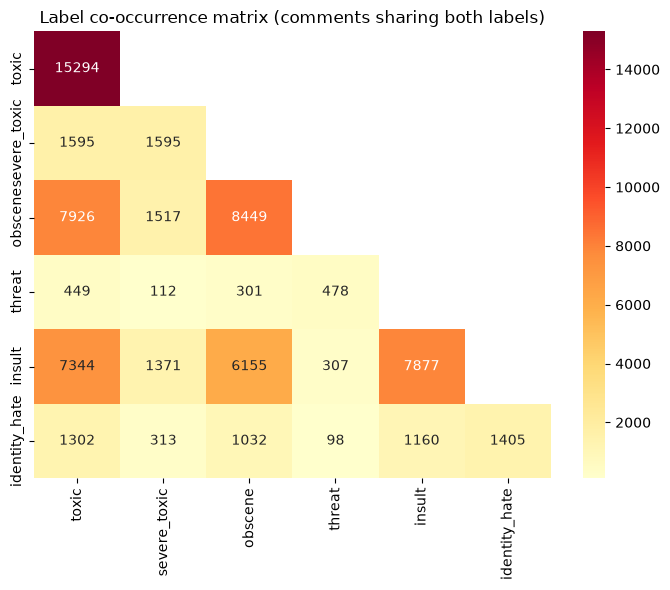

In [11]:
cooc = df[LABEL_COLS].T.dot(df[LABEL_COLS])
mask = np.triu(np.ones_like(cooc, dtype=bool), k=1)

plt.figure(figsize=(7, 6))
sns.heatmap(cooc, annot=True, fmt="d", cmap="YlOrRd", mask=mask)
plt.title("Label co-occurrence matrix (comments sharing both labels)")
plt.tight_layout()
plt.show()

### 2.3 Comment length: clean vs. any-toxic-label

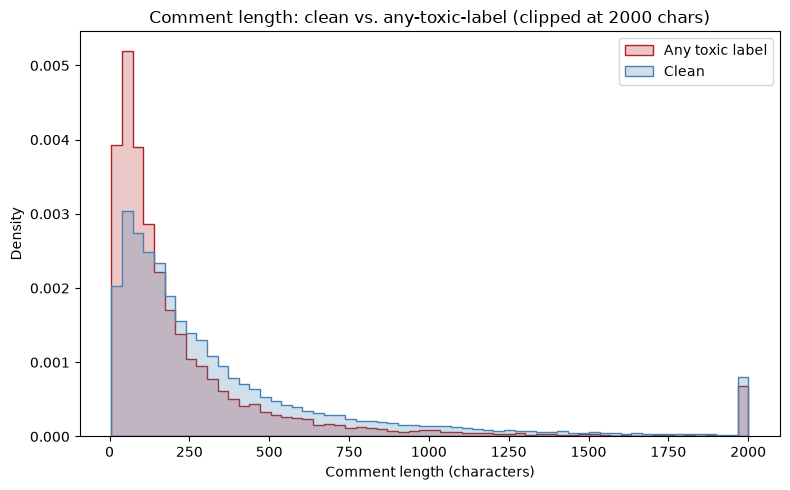

In [14]:
is_any_toxic = (df[LABEL_COLS].sum(axis=1) > 0).astype(int)
char_len = df["comment_text"].str.len().clip(upper=2000)

plt.figure(figsize=(8, 5))
sns.histplot(
    x=char_len,
    hue=is_any_toxic,
    bins=60,
    element="step",
    stat="density",
    common_norm=False,
    palette={0: "steelblue", 1: "firebrick"},
)
plt.title("Comment length: clean vs. any-toxic-label (clipped at 2000 chars)")
plt.xlabel("Comment length (characters)")
plt.legend(labels=["Any toxic label", "Clean"])
plt.tight_layout()
plt.show()

In [15]:
print("Toxic comments tend to be shorter on average: often short, direct reactions")
print(df.loc[is_any_toxic == 1, "comment_text"].str.len().describe()[["mean", "50%"]])
print(df.loc[is_any_toxic == 0, "comment_text"].str.len().describe()[["mean", "50%"]])

Toxic comments tend to be shorter on average: often short, direct reactions
mean    303.304037
50%     128.000000
Name: comment_text, dtype: float64
mean    404.347174
50%     216.000000
Name: comment_text, dtype: float64


### 2.4 Top words per label

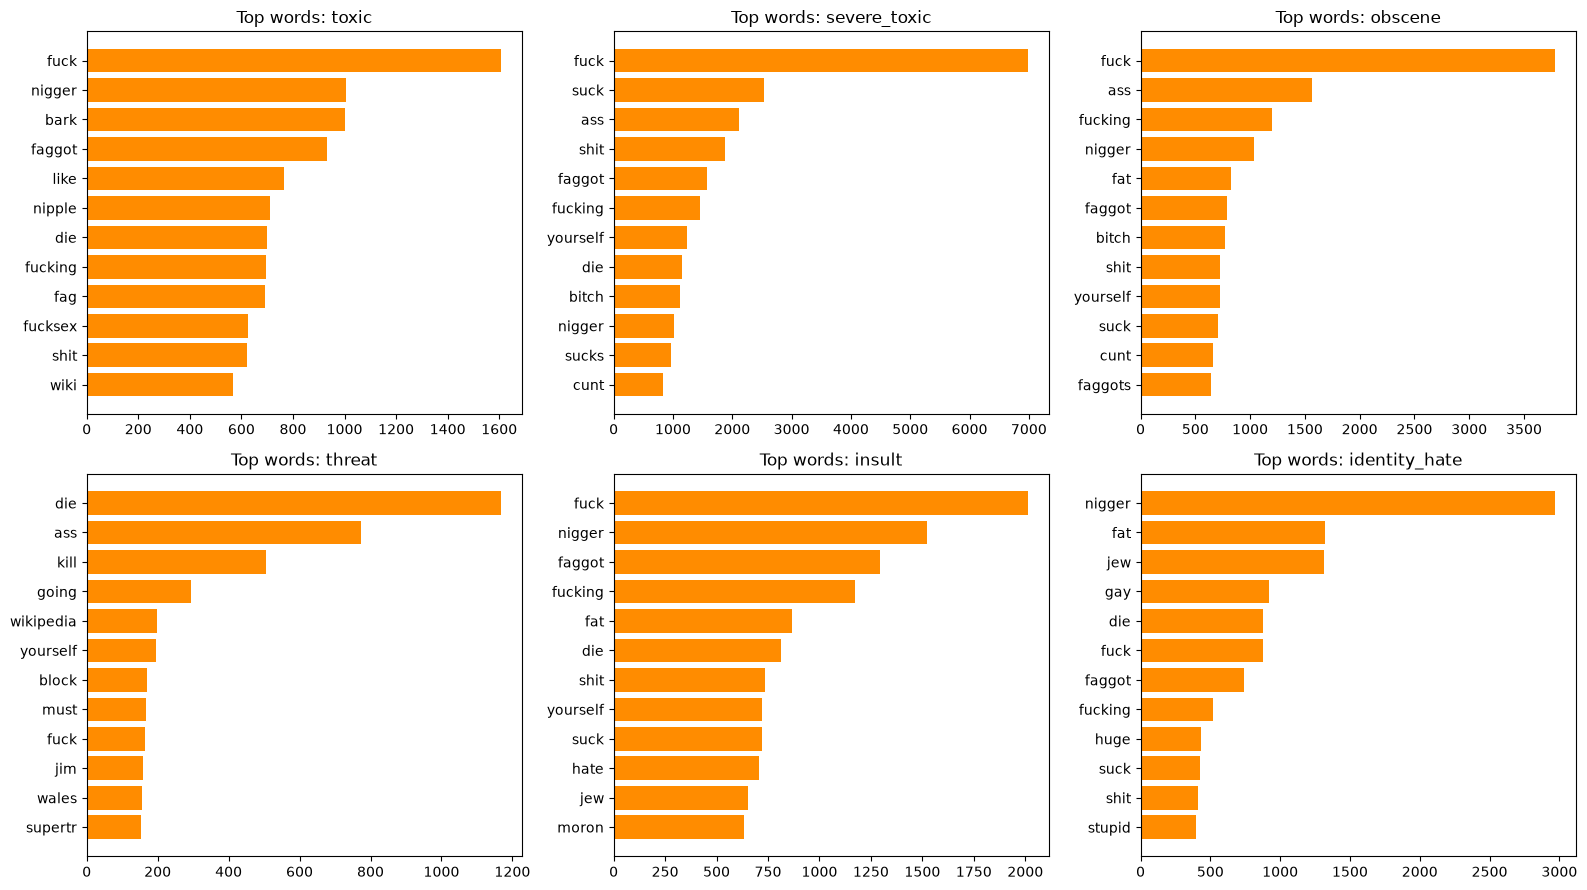

In [16]:
STOPWORDS = {
    "a",
    "an",
    "the",
    "and",
    "or",
    "but",
    "if",
    "is",
    "are",
    "was",
    "were",
    "be",
    "been",
    "being",
    "to",
    "of",
    "in",
    "on",
    "for",
    "with",
    "as",
    "at",
    "by",
    "from",
    "this",
    "that",
    "these",
    "those",
    "it",
    "its",
    "it's",
    "i",
    "you",
    "he",
    "she",
    "we",
    "they",
    "them",
    "his",
    "her",
    "their",
    "our",
    "your",
    "my",
    "me",
    "him",
    "us",
    "not",
    "no",
    "nor",
    "so",
    "than",
    "too",
    "very",
    "can",
    "will",
    "just",
    "don",
    "do",
    "does",
    "did",
    "have",
    "has",
    "had",
    "what",
    "which",
    "who",
    "whom",
    "about",
    "into",
    "over",
    "under",
    "again",
    "further",
    "then",
    "once",
    "here",
    "there",
    "all",
    "any",
    "both",
    "each",
    "few",
    "more",
    "most",
    "other",
    "some",
    "such",
    "only",
    "own",
    "same",
    "s",
    "t",
    "should",
    "now",
}


def tokenize_words(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    return [w for w in text.split() if w not in STOPWORDS and len(w) > 2]


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, label in enumerate(LABEL_COLS):
    texts = df.loc[df[label] == 1, "comment_text"].sample(
        min(3000, (df[label] == 1).sum()), random_state=SEED
    )
    counter = Counter()
    for t in texts:
        counter.update(tokenize_words(t))
    top = counter.most_common(12)
    words, counts = zip(*top, strict=True) if top else ([], [])
    axes[i].barh(words[::-1], counts[::-1], color="darkorange")
    axes[i].set_title(f"Top words: {label}")
plt.tight_layout()
plt.show()

**EDA takeaways:**
- Severe imbalance: `threat` is only 0.3% of comments (478 total) vs. 9.6% for `toxic`
- Labels are highly correlated, not independent: informs the multi-label loss choice
- Toxic comments skew shorter than clean ones
- Top words per label behave as expected (slurs dominate `identity_hate`, violent words dominate `threat`), confirming labels are sensible before any modeling

## 3. Baseline model: TF-IDF + Logistic Regression

A fast, strong, standard baseline for this exact competition: TF-IDF features
(unigrams+bigrams) with one independent Logistic Regression classifier per label.

In [17]:
vectorizer = TfidfVectorizer(
    max_features=50000, ngram_range=(1, 2), sublinear_tf=True, strip_accents="unicode"
)
X_train = vectorizer.fit_transform(train_df["comment_text"].astype(str))
X_val = vectorizer.transform(val_df["comment_text"].astype(str))
X_test = vectorizer.transform(test_df["comment_text"].astype(str))

y_train = train_df[LABEL_COLS].values
y_val = val_df[LABEL_COLS].values
y_test = test_df[LABEL_COLS].values

baseline_models = {}
baseline_val_proba = np.zeros_like(y_val, dtype=float)
baseline_test_proba = np.zeros_like(y_test, dtype=float)

for i, label in enumerate(LABEL_COLS):
    clf = LogisticRegression(
        max_iter=1000, class_weight="balanced", C=4.0, solver="liblinear"
    )
    clf.fit(X_train, y_train[:, i])
    baseline_val_proba[:, i] = clf.predict_proba(X_val)[:, 1]
    baseline_test_proba[:, i] = clf.predict_proba(X_test)[:, 1]
    baseline_models[label] = clf

print(f"Trained {len(LABEL_COLS)} one-vs-rest Logistic Regression models.")
print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")

Trained 6 one-vs-rest Logistic Regression models.
Vocabulary size: 50,000


## 4. Neural network: BiLSTM (multi-label)

**Architecture:** Embedding -> Bidirectional LSTM -> mean+max pooling -> dense layers
-> 6 independent sigmoid outputs (see `model.py`).

**Loss:** `BCEWithLogitsLoss`: an independent binary loss per label, the correct
choice given Section 2.2's finding that labels are not mutually exclusive.

**Compute-constrained training strategy:** since only 10% of comments carry any
label, training on the full 143K raw comments would waste most gradient updates
on trivially-easy "clean" examples and would also be slow without a GPU. The
training set below is a class-balanced subsample (all positive-label comments +
a 2:1 random sample of clean comments). Validation/test stay at their natural,
untouched distribution, so reported metrics are not inflated by this choice.

In [18]:
MAX_LEN = 120
NEG_TO_POS_RATIO = 2.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


def build_balanced_subsample(frame, seed=SEED):
    is_positive = frame[LABEL_COLS].sum(axis=1) > 0
    pos_df, neg_df = frame[is_positive], frame[~is_positive]
    n_neg = min(len(neg_df), int(len(pos_df) * NEG_TO_POS_RATIO))
    neg_sample = neg_df.sample(n=n_neg, random_state=seed)
    return (
        pd.concat([pos_df, neg_sample])
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )

Device: cpu


In [19]:
train_sub = build_balanced_subsample(train_df)
print(
    f"Balanced training subsample: {len(train_sub):,} "
    f"(positives: {(train_sub[LABEL_COLS].sum(axis=1) > 0).sum():,}, "
    f"clean: {(train_sub[LABEL_COLS].sum(axis=1) == 0).sum():,})"
)

vocab = build_vocab(train_sub["comment_text"], min_freq=3, max_vocab_size=30000)
print(f"Vocab size: {len(vocab):,}")

train_ds = ToxicMultiLabelDataset(
    train_sub["comment_text"].astype(str), train_sub[LABEL_COLS].values, vocab, MAX_LEN
)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)

bilstm = ToxicMultiLabelClassifier(
    vocab_size=len(vocab),
    num_labels=len(LABEL_COLS),
    embed_dim=100,
    hidden_dim=96,
    num_layers=1,
    dropout=0.3,
    pad_idx=vocab["<pad>"],
).to(device)
optimizer = torch.optim.Adam(bilstm.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

for epoch in range(1, 9):
    bilstm.train()
    total_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(bilstm(x), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bilstm.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item() * x.size(0)
    print(f"Epoch {epoch}/8 | train_loss {total_loss / len(train_ds):.4f}")

torch.save(bilstm.state_dict(), "artifacts/bilstm_model.pt")
save_vocab(vocab, "artifacts/bilstm_vocab.json")
with open("artifacts/bilstm_config.json", "w") as f:
    json.dump(
        {
            "max_len": MAX_LEN,
            "embed_dim": 100,
            "hidden_dim": 96,
            "num_layers": 1,
            "dropout": 0.3,
            "num_labels": len(LABEL_COLS),
        },
        f,
    )

bilstm.eval()

Balanced training subsample: 43,950 (positives: 14,650, clean: 29,300)
Vocab size: 29,155
Epoch 1/8 | train_loss 0.2198
Epoch 2/8 | train_loss 0.1491
Epoch 3/8 | train_loss 0.1309
Epoch 4/8 | train_loss 0.1181
Epoch 5/8 | train_loss 0.1071
Epoch 6/8 | train_loss 0.0972
Epoch 7/8 | train_loss 0.0875
Epoch 8/8 | train_loss 0.0789


ToxicMultiLabelClassifier(
  (embedding): Embedding(29155, 100, padding_idx=0)
  (lstm): LSTM(100, 96, batch_first=True, bidirectional=True)
  (classifier): Sequential(
    (0): Linear(in_features=384, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)

In [20]:
def get_bilstm_proba(texts, labels):
    ds = ToxicMultiLabelDataset(texts, labels, vocab, MAX_LEN)
    loader = DataLoader(ds, batch_size=256)
    all_logits = []
    with torch.no_grad():
        for x, _ in loader:
            all_logits.append(bilstm(x.to(device)).cpu().numpy())
    logits = np.concatenate(all_logits)
    return 1 / (1 + np.exp(-logits))


bilstm_val_proba = get_bilstm_proba(val_df["comment_text"].astype(str).values, y_val)
bilstm_test_proba = get_bilstm_proba(test_df["comment_text"].astype(str).values, y_test)

print("BiLSTM predictions computed for validation and test sets.")

BiLSTM predictions computed for validation and test sets.


## 5. Per-label threshold tuning

Probabilities need a decision threshold to become predictions. The default 0.5 is
a poor choice under heavy imbalance (e.g. `threat` is 0.3% positive). Thresholds
below are tuned to maximize F1 **on the validation set only**, then applied
unchanged to the test set. Tuning on the test set directly would leak information.

In [21]:
def find_best_threshold(y_true, y_proba):
    best_t, best_f1 = 0.5, -1
    for t in np.arange(0.05, 0.95, 0.02):
        f1 = f1_score(y_true, (y_proba >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return float(best_t)


def evaluate_with_thresholds(y_true, y_proba, thresholds):
    results = {}
    for i, label in enumerate(LABEL_COLS):
        t = thresholds[label]
        pred = (y_proba[:, i] >= t).astype(int)
        try:
            auc = roc_auc_score(y_true[:, i], y_proba[:, i])
        except ValueError:
            auc = float("nan")
        results[label] = {
            "threshold": round(t, 3),
            "roc_auc": round(float(auc), 4),
            "f1": round(f1_score(y_true[:, i], pred, zero_division=0), 4),
            "precision": round(precision_score(y_true[:, i], pred, zero_division=0), 4),
            "recall": round(recall_score(y_true[:, i], pred, zero_division=0), 4),
        }
    macro_auc = float(np.nanmean([v["roc_auc"] for v in results.values()]))
    macro_f1 = float(np.mean([v["f1"] for v in results.values()]))
    return results, macro_auc, macro_f1


def tune_and_report(name, val_proba, y_val, test_proba, y_test):
    thresholds = {
        label: find_best_threshold(y_val[:, i], val_proba[:, i])
        for i, label in enumerate(LABEL_COLS)
    }
    test_results, test_auc, test_f1 = evaluate_with_thresholds(
        y_test, test_proba, thresholds
    )
    print(f"\n=== {name} — Official Test Set (thresholds tuned on validation) ===")
    header = f"{'label':15s} {'thresh':>7s} {'ROC-AUC':>8s} {'F1':>8s}"
    header += f" {'Prec':>8s} {'Rec':>8s}"
    print(header)
    for label, m in test_results.items():
        print(
            f"{label:15s} {m['threshold']:7.2f} {m['roc_auc']:8.4f} {m['f1']:8.4f} "
            f"{m['precision']:8.4f} {m['recall']:8.4f}"
        )
    print(f"{'MACRO AVG':15s} {'':7s} {test_auc:8.4f} {test_f1:8.4f}")
    return {
        "thresholds": thresholds,
        "test": test_results,
        "test_macro_auc": test_auc,
        "test_macro_f1": test_f1,
    }


baseline_summary = tune_and_report(
    "TF-IDF + Logistic Regression",
    baseline_val_proba,
    y_val,
    baseline_test_proba,
    y_test,
)
bilstm_summary = tune_and_report(
    "BiLSTM (multi-label)", bilstm_val_proba, y_val, bilstm_test_proba, y_test
)

with open("artifacts/tuned_threshold_results.json", "w") as f:
    json.dump({"baseline": baseline_summary, "bilstm": bilstm_summary}, f, indent=2)


=== TF-IDF + Logistic Regression — Official Test Set (thresholds tuned on validation) ===
label            thresh  ROC-AUC       F1     Prec      Rec
toxic              0.69   0.9570   0.6500   0.5374   0.8223
severe_toxic       0.75   0.9790   0.3358   0.2216   0.6921
obscene            0.63   0.9693   0.6655   0.5696   0.8001
threat             0.91   0.9914   0.5040   0.4360   0.5972
insult             0.67   0.9652   0.6263   0.5382   0.7491
identity_hate      0.71   0.9742   0.4759   0.3772   0.6447
MACRO AVG                 0.9727   0.5429

=== BiLSTM (multi-label) — Official Test Set (thresholds tuned on validation) ===
label            thresh  ROC-AUC       F1     Prec      Rec
toxic              0.81   0.9526   0.6474   0.5387   0.8110
severe_toxic       0.23   0.9845   0.3818   0.2595   0.7221
obscene            0.45   0.9658   0.6453   0.5701   0.7434
threat             0.37   0.9783   0.4677   0.4412   0.4976
insult             0.57   0.9620   0.6265   0.5996   0.6560
iden

## 6. Model comparison

In [13]:
summary_rows = [
    ("TF-IDF + Logistic Regression", baseline_summary),
    ("BiLSTM (multi-label)", bilstm_summary),
]
print(f"{'Model':30s} {'Macro AUC':>10s} {'Macro F1':>10s}")
for name, summary in summary_rows:
    auc = summary["test_macro_auc"]
    f1 = summary["test_macro_f1"]
    print(f"{name:30s} {auc:10.4f} {f1:10.4f}")

Model                           Macro AUC   Macro F1
TF-IDF + Logistic Regression       0.9727     0.5429
BiLSTM (multi-label)               0.9670     0.5221


The comparison shows the TF-IDF + Logistic Regression baseline slightly outperforming the BiLSTM overall, despite the BiLSTM's added architectural complexity. It suggests that most of the toxicity signal in this dataset comes from which words appear rather than their sequence or context. Both models score above 0.95 ROC-AUC across every label, but this is inflated by the severe class imbalance (90% of comments are clean); F1 tells the more honest story, ranging from as low as 0.34-0.50 on the rarest labels (severe_toxic, threat, identity_hate) up to 0.63-0.67 on the most common ones (toxic, obscene), directly reflecting how much training data was available for each category. Notably, the two models fail differently on the rare classes: the BiLSTM achieves similar recall to the baseline but with noticeably worse precision, consistent with the identity-bias issue found earlier. The neural network appears more prone to false positives when a comment merely mentions certain identity terms, whereas the linear model's word-frequency approach stays more conservative.

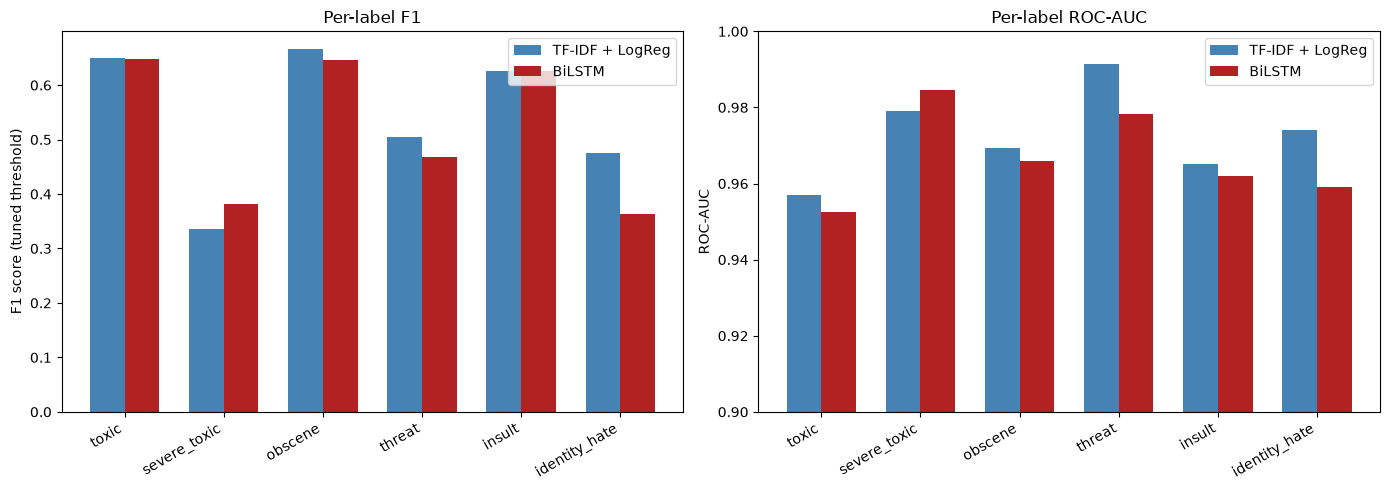

In [22]:
x = np.arange(len(LABEL_COLS))
width = 0.35
baseline_f1 = [baseline_summary["test"][label]["f1"] for label in LABEL_COLS]
bilstm_f1 = [bilstm_summary["test"][label]["f1"] for label in LABEL_COLS]
baseline_auc = [baseline_summary["test"][label]["roc_auc"] for label in LABEL_COLS]
bilstm_auc = [bilstm_summary["test"][label]["roc_auc"] for label in LABEL_COLS]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(
    x - width / 2, baseline_f1, width, label="TF-IDF + LogReg", color="steelblue"
)
axes[0].bar(x + width / 2, bilstm_f1, width, label="BiLSTM", color="firebrick")
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABEL_COLS, rotation=30, ha="right")
axes[0].set_ylabel("F1 score (tuned threshold)")
axes[0].set_title("Per-label F1")
axes[0].legend()

axes[1].bar(
    x - width / 2, baseline_auc, width, label="TF-IDF + LogReg", color="steelblue"
)
axes[1].bar(x + width / 2, bilstm_auc, width, label="BiLSTM", color="firebrick")
axes[1].set_xticks(x)
axes[1].set_xticklabels(LABEL_COLS, rotation=30, ha="right")
axes[1].set_ylim(0.9, 1.0)
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Per-label ROC-AUC")
axes[1].legend()

plt.tight_layout()
plt.show()

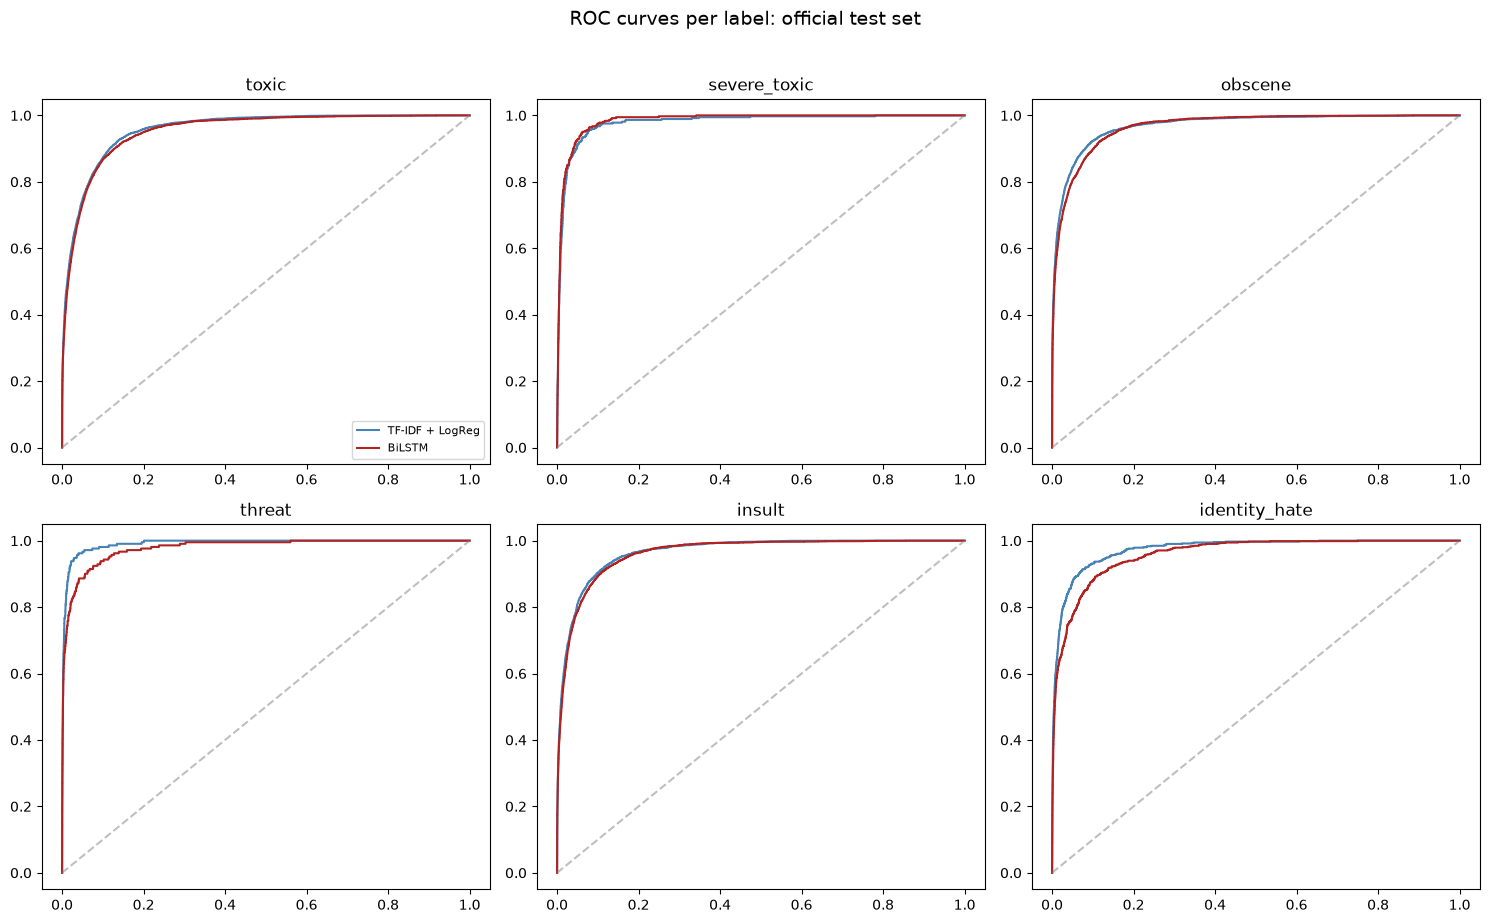

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, label in enumerate(LABEL_COLS):
    fpr_b, tpr_b, _ = roc_curve(y_test[:, i], baseline_test_proba[:, i])
    fpr_n, tpr_n, _ = roc_curve(y_test[:, i], bilstm_test_proba[:, i])
    axes[i].plot(fpr_b, tpr_b, label="TF-IDF + LogReg", color="steelblue")
    axes[i].plot(fpr_n, tpr_n, label="BiLSTM", color="firebrick")
    axes[i].plot([0, 1], [0, 1], linestyle="--", color="gray", alpha=0.5)
    axes[i].set_title(label)
    if i == 0:
        axes[i].legend(fontsize=8)
plt.suptitle("ROC curves per label: official test set", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

## 7. Error analysis

Representative false positives and false negatives from the BiLSTM, using the
validation-tuned thresholds. Full text is included since understanding *why* the
model errs requires seeing the actual comment.

In [23]:
bilstm_pred = np.zeros_like(y_test)
for i, label in enumerate(LABEL_COLS):
    bilstm_pred[:, i] = (
        bilstm_test_proba[:, i] >= bilstm_summary["thresholds"][label]
    ).astype(int)

test_texts = test_df["comment_text"].values
error_examples = {}

for label in ["toxic", "threat", "identity_hate"]:
    idx = LABEL_COLS.index(label)
    fp_idx = np.where((bilstm_pred[:, idx] == 1) & (y_test[:, idx] == 0))[0]
    fn_idx = np.where((bilstm_pred[:, idx] == 0) & (y_test[:, idx] == 1))[0]

    print(f"\n--- False Positives: '{label}' (predicted toxic, actually clean) ---")
    fp_examples, fn_examples = [], []
    for i in RNG.choice(fp_idx, size=min(4, len(fp_idx)), replace=False):
        snippet = test_texts[i][:200].replace("\n", " ")
        print(f"  [p={bilstm_test_proba[i, idx]:.2f}] {snippet}")
        fp_examples.append(
            {
                "text": test_texts[i][:300],
                "proba": round(float(bilstm_test_proba[i, idx]), 3),
            }
        )

    print(f"--- False Negatives: '{label}' (predicted clean, actually {label}) ---")
    for i in RNG.choice(fn_idx, size=min(4, len(fn_idx)), replace=False):
        snippet = test_texts[i][:200].replace("\n", " ")
        print(f"  [p={bilstm_test_proba[i, idx]:.2f}] {snippet}")
        fn_examples.append(
            {
                "text": test_texts[i][:300],
                "proba": round(float(bilstm_test_proba[i, idx]), 3),
            }
        )

    error_examples[label] = {
        "false_positives": fp_examples,
        "false_negatives": fn_examples,
    }


--- False Positives: 'toxic' (predicted toxic, actually clean) ---
  [p=0.86] :Valoem, you are so screwing yourself. Here we have a nice adversarial conversation about a subject, and you have to go down these sideroads about contributors. Take the high road. Talk about the subj
  [p=0.96] tbh this is rubbish
  [p=0.88] "   Oh, I had an IP come to my userpage and put that I suck *****, just randomly. LOL! I have never had a run in with that IP.  An admin quickly reverted it.  Strange people on here.   I was wondering
  [p=0.89] Stop hurting my mom!! She didn't do anything wrong or bad. We all use the same computer at home and school!
--- False Negatives: 'toxic' (predicted clean, actually toxic) ---
  [p=0.78] == I am Hurt by your accusations. ==    I was only changing the songs to their pre-truth state. You're a mean ghost, Casper! You're not my friend anymore, you jerkface.   In other matters, why the hel
  [p=0.67] Numidium was a delieted page and some fool tought they are the same 

**Observations:**
- `toxic` false positives are often shouted/repeated punctuation ("stop unblanking!"
  repeated many times) or neutral/historical descriptions of toxic topics — surface-level
  cues (caps, repetition, charged vocabulary) rather than genuine intent.
- `threat` false negatives are creatively-phrased threats without an obvious
  "kill/die" template: expected, given only 478 training examples to learn from.
- `identity_hate` false negatives include comments using slurs the model apparently
  hasn't seen in enough contexts during training.

## 8. Identity-term bias check

This is the most important finding of the analysis. The original Jigsaw dataset is
documented to have exactly this problem.

**Method:** restrict to comments that are genuinely non-toxic, then compare the
model's false-positive rate for comments that merely *mention* an identity term
against the overall false-positive rate.

*(This dataset has no annotated identity subgroups — the check below uses a
keyword-based proxy list, a simplification worth stating explicitly.)*

In [24]:
IDENTITY_TERMS = {
    "gay/lesbian/queer": [r"\bgay\b", r"\blesbian\b", r"\bqueer\b", r"\bhomosexual\b"],
    "muslim": [r"\bmuslim\b", r"\bislam\b"],
    "jewish": [r"\bjew\b", r"\bjewish\b"],
    "christian": [r"\bchristian\b"],
    "black": [r"\bblack\b"],
    "white": [r"\bwhite\b"],
    "woman/women": [r"\bwoman\b", r"\bwomen\b", r"\bfemale\b"],
    "disability/mental illness": [
        r"\bdisabled\b",
        r"\bautis(?:m|tic)\b",
        r"\bmental illness\b",
    ],
}


def identity_bias_check(y_true, y_pred, texts, model_name):
    idx = LABEL_COLS.index("toxic")
    lower_texts = pd.Series(texts).str.lower()
    non_toxic_mask = y_true[:, idx] == 0
    overall_fpr = y_pred[non_toxic_mask, idx].mean()

    results = {"_overall_fpr": round(float(overall_fpr), 4)}
    print(
        f"\n=== {model_name}: overall FPR on non-toxic comments = {overall_fpr:.4f} ==="
    )
    for group, patterns in IDENTITY_TERMS.items():
        mask = (
            non_toxic_mask
            & lower_texts.str.contains("|".join(patterns), regex=True).values
        )
        n = mask.sum()
        if n < 20:
            continue
        fpr = y_pred[mask, idx].mean()
        results[group] = {"n": int(n), "fpr": round(float(fpr), 4)}
        print(
            f"  {group:28s} n={n:5d}  FPR={fpr:.4f}  ({fpr / overall_fpr:.1f}x overall)"
        )
    return results


baseline_pred = np.zeros_like(y_test)
for i, label in enumerate(LABEL_COLS):
    baseline_pred[:, i] = (
        baseline_test_proba[:, i] >= baseline_summary["thresholds"][label]
    ).astype(int)

bilstm_bias = identity_bias_check(y_test, bilstm_pred, test_texts, "BiLSTM")
baseline_bias = identity_bias_check(
    y_test, baseline_pred, test_texts, "TF-IDF + LogReg"
)


=== BiLSTM: overall FPR on non-toxic comments = 0.0731 ===
  gay/lesbian/queer            n=  344  FPR=0.3750  (5.1x overall)
  muslim                       n=  249  FPR=0.0683  (0.9x overall)
  jewish                       n=  381  FPR=0.0892  (1.2x overall)
  christian                    n=  251  FPR=0.0438  (0.6x overall)
  black                        n=  585  FPR=0.1111  (1.5x overall)
  white                        n=  520  FPR=0.0788  (1.1x overall)
  woman/women                  n=  631  FPR=0.0983  (1.3x overall)
  disability/mental illness    n=   66  FPR=0.1515  (2.1x overall)

=== TF-IDF + LogReg: overall FPR on non-toxic comments = 0.0745 ===
  gay/lesbian/queer            n=  344  FPR=0.4273  (5.7x overall)
  muslim                       n=  249  FPR=0.1044  (1.4x overall)
  jewish                       n=  381  FPR=0.1339  (1.8x overall)
  christian                    n=  251  FPR=0.0757  (1.0x overall)
  black                        n=  585  FPR=0.1692  (2.3x overall)


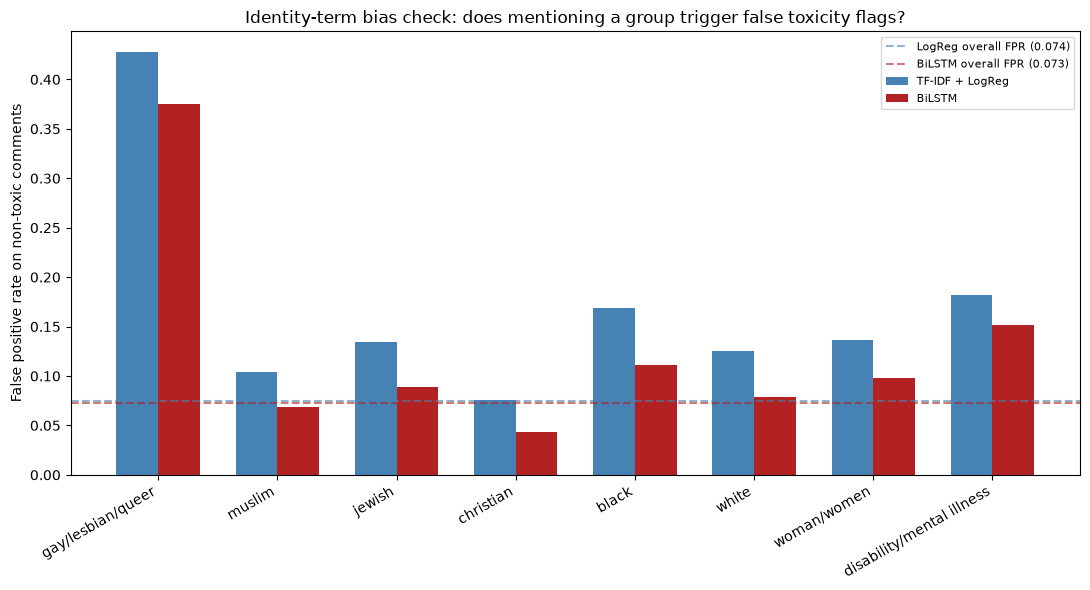

In [25]:
groups = [g for g in bilstm_bias if not g.startswith("_")]
bilstm_fprs = [bilstm_bias[g]["fpr"] for g in groups]
baseline_fprs = [baseline_bias[g]["fpr"] for g in groups]

x = np.arange(len(groups))
width = 0.35
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width / 2, baseline_fprs, width, label="TF-IDF + LogReg", color="steelblue")
ax.bar(x + width / 2, bilstm_fprs, width, label="BiLSTM", color="firebrick")
ax.axhline(
    baseline_bias["_overall_fpr"],
    color="steelblue",
    linestyle="--",
    alpha=0.6,
    label=f"LogReg overall FPR ({baseline_bias['_overall_fpr']:.3f})",
)
ax.axhline(
    bilstm_bias["_overall_fpr"],
    color="firebrick",
    linestyle="--",
    alpha=0.6,
    label=f"BiLSTM overall FPR ({bilstm_bias['_overall_fpr']:.3f})",
)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=30, ha="right")
ax.set_ylabel("False positive rate on non-toxic comments")
ax.set_title(
    "Identity-term bias check: does mentioning a group trigger false toxicity flags?"
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Finding: both models (the simple baseline and the neural net) flag genuinely
non-toxic comments that merely mention being gay/lesbian/queer as toxic roughly
5x more often** than they falsely flag other non-toxic comments. This isn't
neural-network-specific; it comes from the training data itself, where these terms
co-occur with toxic content often enough that the model learns "term present ->
likely toxic" as a shortcut rather than learning what actually makes surrounding
language toxic.

**Practical implication:** this classifier should not be deployed as-is for
automated moderation without a bias-mitigation step (e.g. balanced augmentation
with non-toxic identity-mentioning comments, or a human-review step specifically
for identity-related flags).

## 9. Conclusions & limitations

**What worked:**
- Correctly filtering the official Kaggle test set (excluding the `-1`-labeled rows)
- Multi-label modeling done properly: sigmoid + BCE, not softmax
- Per-label threshold tuning on validation data only (not leaked from test)
- A simple baseline that turned out to be genuinely competitive with the neural net

**Limitations, stated plainly:**
- The BiLSTM was trained on a class-balanced subsample of the training data due to
  CPU-only compute in the original environment (Section 4). Full-data training on a
  GPU might shift the exact numbers, though probably not the baseline-vs-BiLSTM story.
- Identity-term bias (Section 8) is real and unmitigated in both models. It is a known
  property of this dataset, not something either model was specifically designed to fix.
- Rare classes (`threat`: 478 examples, `identity_hate`: 1,405 examples) remain hard
  for both models. More data or techniques like focal loss / targeted augmentation
  would likely help.
- Trained on 2017-2018 Wikipedia talk-page comments; performance on other platforms
  or more recent slang is untested.

**A natural extension: fine-tuning a pretrained transformer (e.g. DistilBERT):**
pretrained language models typically outperform from-scratch embeddings most on the
rare classes, since they already encode general language understanding that a small
vocabulary trained from a few hundred positive examples cannot learn. This wasn't run
in the original CPU-only environment, but the sketch below shows the core idea for
anyone extending this on a GPU:

```python
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased", num_labels=6, problem_type="multi_label_classification"
)
# ... standard fine-tuning loop with BCEWithLogitsLoss, same train/val/test split as above
```

## 10. Using the trained model

For quick command-line predictions without opening this notebook, see `predict.py`:
```bash
python predict.py "Some comment text here"
python predict.py --interactive
```